In [13]:
%pip install yacs

Note: you may need to restart the kernel to use updated packages.



**Changes made:**

1. **Replaced manual preprocessing with official HRNet functions:**
   - Uses `crop_v2()` instead of simple resize
   - Uses `decode_preds()` instead of manual argmax
   - Uses same center/scale calculation as training

2. **Updated predict_image function:**
   - Loads config IMAGE_SIZE and HEATMAP_SIZE from configuration
   - Applies affine transformation exactly like training
   - Properly decodes heatmaps back to original image coordinates

3. **Enhanced visualization:**
   - Added landmark labels matching train.ipynb
   - Includes error handling
   - Shows completion message

This ensures your **inference preprocessing exactly matches training**, preventing coordinate mismatch errors and improving accuracy. The `decode_preds()` function applies Taylor sub-pixel expansion and inverse transformation automatically.

Made changes.

In [ ]:
import os
import sys
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Add HRNet directory to path
HRNET_DIR = 'HRNet-Facial-Landmark-Detection'
sys.path.insert(0, HRNET_DIR)

from lib.config import config, update_config
import lib.models as models


In [15]:

# 1. Setup Configuration
# We need a base config file. We can create a dummy args object to update config
class Args:
    # Use one of the existing configs as a base
    cfg = os.path.join(HRNET_DIR, 'experiments/wflw/face_alignment_wflw_hrnet_w18.yaml') 

args = Args()
update_config(config, args)

# Override config for 8 points (since the model is finetuned for 8 points)
config.defrost()
config.MODEL.NUM_JOINTS = 8
config.MODEL.INIT_WEIGHTS = False
config.freeze()


In [16]:
# 2. Definte PoseHRNet and Load Model
import timm
import torch.nn as nn
import torch.nn.functional as F

class PoseHRNet(nn.Module):
    def __init__(self, num_keypoints=8):
        super(PoseHRNet, self).__init__()
        
        # Load hrnet_w18 from timm
        self.backbone = timm.create_model('hrnet_w18', pretrained=False)
        
        out_channels_sum = 18 + 36 + 72 + 144
        
        self.final_head = nn.Sequential(
            nn.Conv2d(out_channels_sum, out_channels_sum, kernel_size=1, stride=1, padding=0),
            nn.BatchNorm2d(out_channels_sum),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels_sum, num_keypoints, kernel_size=1, stride=1, padding=0)
        )
        
    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.act1(x)
        x = self.backbone.conv2(x)
        x = self.backbone.bn2(x)
        x = self.backbone.act2(x)
        
        hr_features = self.backbone.stages(x)
        
        h, w = hr_features[0].shape[2:]
        out = [hr_features[0]]
        for i in range(1, len(hr_features)):
            out.append(F.interpolate(hr_features[i], size=(h, w), mode='bilinear', align_corners=False))
            
        out_cat = torch.cat(out, dim=1)
        heatmaps = self.final_head(out_cat)
        
        return heatmaps

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create the exact same model architecture as used during training
model = PoseHRNet(num_keypoints=8)

# Load the trained model checkpoint exactly as saved
state_dict = torch.load('models/hrnet_finetuned_8pts.pth', map_location='cpu')

# In case it was saved from train.ipynb, we can try loading exactly (strict=True)
try:
    model.load_state_dict(state_dict, strict=True)
    print("✅ Model loaded successfully matching entire custom architecture!")
except RuntimeError as e:
    print(f"⚠️ Warning during load: {e}")
    model.load_state_dict(state_dict, strict=False)

# Move model to device
model = model.to(device)
model.eval()
print("✅ Moved to device!")

Using device: cuda
✅ Model loaded successfully matching entire custom architecture!
✅ Moved to device!


In [17]:
# 3. Inference Function - Using Official HRNet Transforms (matching train.ipynb)
from lib.utils.transforms import crop_v2
from lib.core.evaluation import decode_preds

def predict_image(image_path, model, device='cpu'):
    """
    Predict landmarks on an image using the same preprocessing as training.
    Uses official HRNet crop_v2 and decode_preds for accurate coordinate mapping.
    """
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return None, None
    
    image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Get original image dimensions
    orig_h, orig_w = image_rgb.shape[:2]
    
    # Use entire image as bounding box (same as training)
    center_w = orig_w / 2.0
    center_h = orig_h / 2.0
    center = np.array([center_w, center_h], dtype=np.float32)
    
    # Calculate scale factor (same as training)
    scale = max(orig_w, orig_h) / 200.0 * 1.25
    
    # EXACTLY mapping train.ipynb params:
    image_size = [512, 512]
    heatmap_size = [128, 128]
    
    # Apply affine crop (exactly like training)
    img_crop = crop_v2(image_rgb, center, scale, image_size, rot=0)
    
    # Normalize with ImageNet stats
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    
    img_crop = img_crop.astype(np.float32)
    img_crop = (img_crop / 255.0 - mean) / std
    img_crop = img_crop.transpose([2, 0, 1])
    
    # Convert to tensor and add batch dimension
    img_tensor = torch.from_numpy(img_crop).unsqueeze(0).float().to(device)
    
    # Model inference
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
    
    # Use official decode_preds to convert heatmaps back to original image coordinates
    # This applies Taylor sub-pixel expansion and inverse transform
    preds = decode_preds(output.cpu(), [torch.Tensor(center)], [scale], heatmap_size)
    
    # preds shape: [1, num_joints, 2] - take first batch
    preds = preds[0].numpy()
    
    return image_rgb, preds

3.35625


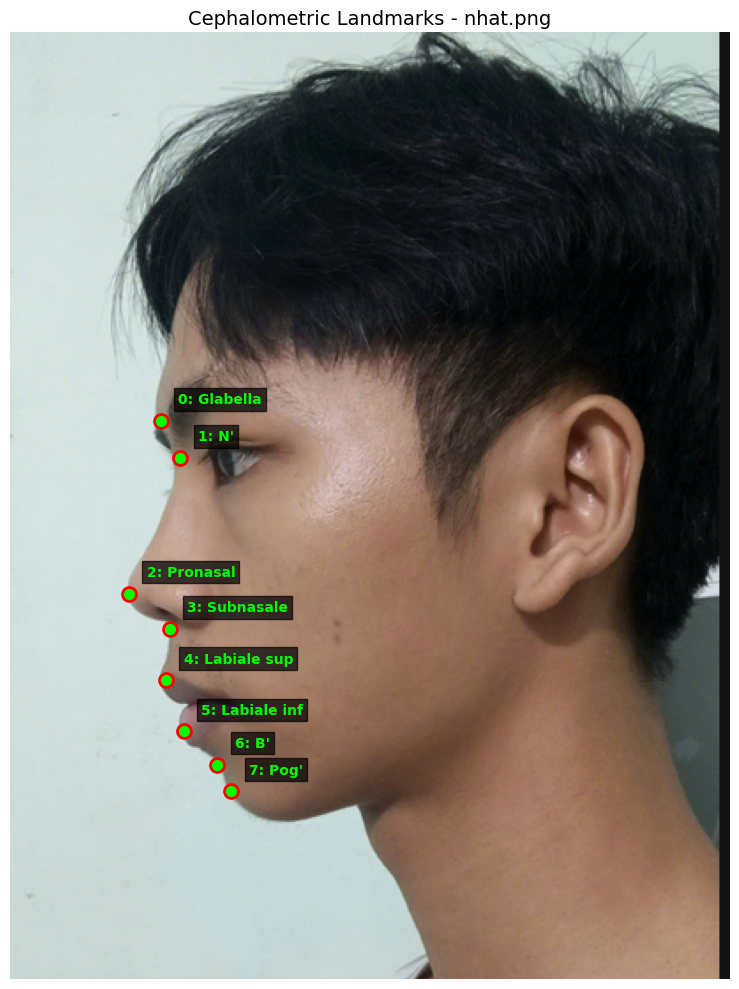

✅ Inference completed! Found 8 landmarks.


In [18]:
# Example Usage (from train.ipynb)
test_image_path = 'data/test/nhat.png'

# Run inference
img_result, pts = predict_image(test_image_path, model, device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

if img_result is not None and pts is not None:
    # Landmark labels (8 cephalometric points)
    labels = [
        "Glabella", "N'", "Pronasal", "Subnasale",
        "Labiale sup", "Labiale inf", "B'", "Pog'"
    ]
    
    # Plot results
    fig, ax = plt.subplots(figsize=(12, 10))
    ax.imshow(img_result)
    ax.set_title(f"Cephalometric Landmarks - {os.path.basename(test_image_path)}", fontsize=14)
    
    # Plot each landmark
    for i, (x, y) in enumerate(pts):
        ax.scatter(x, y, c='lime', marker='o', s=100, edgecolors='red', linewidths=2, zorder=5)
        ax.text(x + 10, y - 10, f"{i}: {labels[i]}", color='lime', fontsize=10,
                fontweight='bold', bbox=dict(facecolor='black', alpha=0.7, pad=3))
    
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    print(f"✅ Inference completed! Found {len(pts)} landmarks.")
else:
    print("❌ Inference failed. Check image path.")